#### Import the libraries

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [38]:
dataset = pd.read_csv(r"C:\Users\srimu\Downloads\scores_data.csv") 

In [3]:
dataset

,Batch,User_ID,Score
0,AI_ELITE_7,uid_149,6 / 7
1,AI_ELITE_7,uid_148,6 / 7
2,AI_ELITE_7,uid_147,7 / 7
3,AI_ELITE_7,uid_146,7 / 7
4,AI_ELITE_7,uid_145,4 / 7
...,...,...,...
144,AI_ELITE_4,uid_5,4 / 7
145,AI_ELITE_4,uid_4,4 / 7
146,AI_ELITE_4,uid_3,4 / 7
147,AI_ELITE_4,uid_2,3 / 7


### Project Description

Batch - Represents the Batch Name

User_ID - Represents the unique student id

Score - Represents the Score out of 7

In [4]:
dataset = pd.DataFrame(dataset)

In [5]:
dataset.columns = dataset.columns.str.strip()

In [6]:
print(dataset.columns)

Index(['Batch', 'User_ID', 'Score'], dtype='object')


In [7]:
dataset['Batch'].unique()

array(['AI_ELITE_7', 'AI_ELITE_6', 'AI_ELITE_4'], dtype=object)

In [8]:
dataset['User_ID'].unique()

array(['uid_149', 'uid_148', 'uid_147', 'uid_146', 'uid_145', 'uid_144',
       'uid_143', 'uid_142', 'uid_141', 'uid_140', 'uid_139', 'uid_138',
       'uid_137', 'uid_136', 'uid_135', 'uid_134', 'uid_133', 'uid_132',
       'uid_131', 'uid_130', 'uid_129', 'uid_128', 'uid_127', 'uid_126',
       'uid_125', 'uid_124', 'uid_123', 'uid_122', 'uid_121', 'uid_120',
       'uid_119', 'uid_118', 'uid_117', 'uid_116', 'uid_115', 'uid_114',
       'uid_113', 'uid_112', 'uid_111', 'uid_110', 'uid_109', 'uid_108',
       'uid_107', 'uid_106', 'uid_105', 'uid_104', 'uid_103', 'uid_102',
       'uid_101', 'uid_100', 'uid_99', 'uid_98', 'uid_97', 'uid_96',
       'uid_95', 'uid_94', 'uid_93', 'uid_92', 'uid_91', 'uid_90',
       'uid_89', 'uid_88', 'uid_87', 'uid_86', 'uid_85', 'uid_84',
       'uid_83', 'uid_82', 'uid_81', 'uid_80', 'uid_79', 'uid_78',
       'uid_77', 'uid_76', 'uid_75', 'uid_74', 'uid_73', 'uid_72',
       'uid_71', 'uid_70', 'uid_69', 'uid_68', 'uid_67', 'uid_66',
       'uid_

In [9]:
dataset['Score'].unique()

array(['6 / 7', '7 / 7', '4 / 7', '5 / 7', '3 / 7', '2 / 7', '0 / 7',
       '1 / 7'], dtype=object)

In [10]:
dataset['Actual_Score'] = dataset['Score'].apply(lambda x: int(x.split('/')[0]))

In [11]:
dataset.head()

,Batch,User_ID,Score,Actual_Score
0,AI_ELITE_7,uid_149,6 / 7,6
1,AI_ELITE_7,uid_148,6 / 7,6
2,AI_ELITE_7,uid_147,7 / 7,7
3,AI_ELITE_7,uid_146,7 / 7,7
4,AI_ELITE_7,uid_145,4 / 7,4


In [12]:
dataset.tail()

,Batch,User_ID,Score,Actual_Score
144,AI_ELITE_4,uid_5,4 / 7,4
145,AI_ELITE_4,uid_4,4 / 7,4
146,AI_ELITE_4,uid_3,4 / 7,4
147,AI_ELITE_4,uid_2,3 / 7,3
148,AI_ELITE_4,uid_1,2 / 7,2


In [31]:
dataset.isnull().sum() #no null values present

Batch           0
User_ID         0
Score           0
Actual_Score    0
dtype: int64

## Data Visualization

### Univariate Analysis

#### Hist plot

C:\Users\srimu\innomatics\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


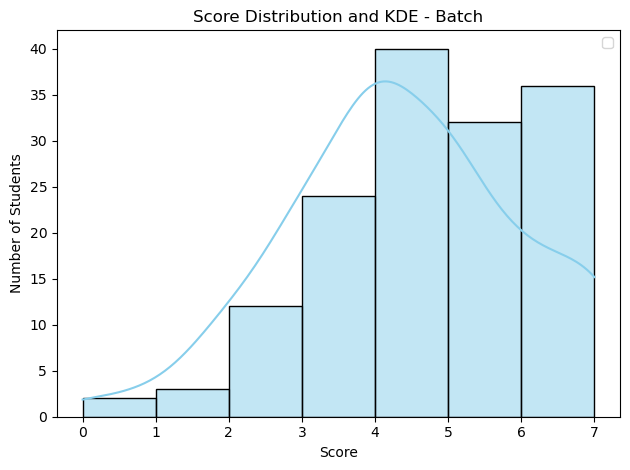

In [14]:
sns.histplot(dataset['Actual_Score'], kde=True, bins=7, color='skyblue', edgecolor='black')
plt.title(f"Score Distribution and KDE - {'Batch'}")
plt.xlabel('Score')
plt.ylabel('Number of Students')
plt.legend()
plt.tight_layout()

#### Pie chart

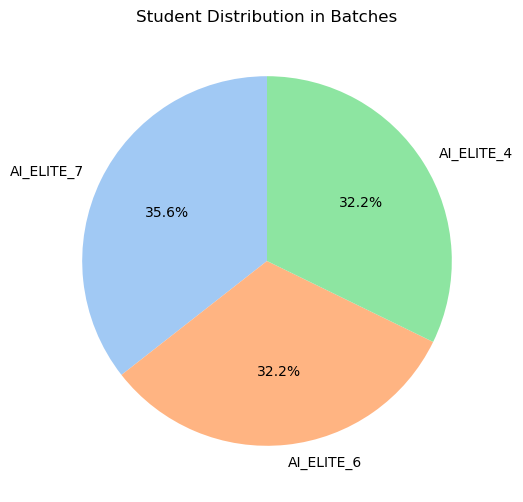

In [21]:
batch_counts = dataset["Batch"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(batch_counts, labels=batch_counts.index, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("pastel"))
plt.title("Student Distribution in Batches")
plt.show()

#### Box plot

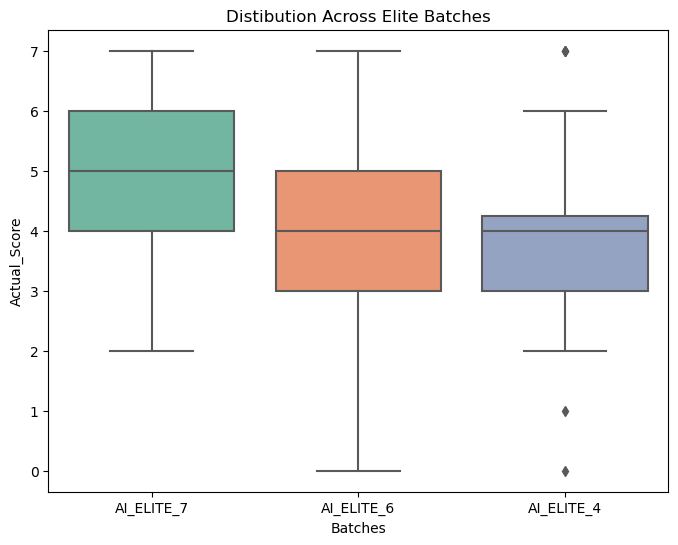

In [25]:
plt.figure(figsize = (8, 6))
sns.boxplot(x = dataset['Batch'], y = dataset['Actual_Score'], data=dataset, palette='Set2')
plt.title('Distibution Across Elite Batches')
plt.xlabel('Batches')
plt.ylabel('Actual_Score')
plt.show()

#### Bar Plot

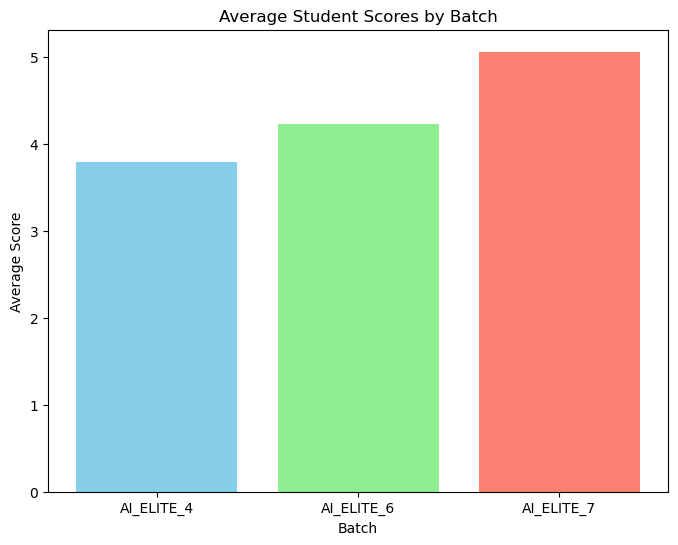

In [36]:
avg_scores = dataset.groupby('Batch')['Actual_Score'].mean()

plt.figure(figsize=(8,6))
plt.bar(avg_scores.index, avg_scores.values, color=['skyblue','lightgreen','salmon'])

plt.title('Average Student Scores by Batch')
plt.xlabel('Batch')
plt.ylabel('Average Score')
plt.show()


### BIvariate Analysis

#### Groupby(Descriptive Analysis)

In [32]:
groupby = dataset.groupby('Batch')['Actual_Score'].agg(count='count', mean='mean', max='max', std='std', full_score=lambda x: (x==7).sum(), below_avg=lambda x: (x<x.mean()).sum())

In [33]:
groupby

,count,mean,max,std,full_score,below_avg
Batch,,,,,,
AI_ELITE_4,48,3.791667,7,1.443376,3,17
AI_ELITE_6,48,4.229167,7,1.640441,5,26
AI_ELITE_7,53,5.056604,7,1.446682,10,30


#### Crosstab

In [34]:
pd.crosstab(dataset["Batch"], dataset["Actual_Score"])

Actual_Score,0,1,2,3,4,5,6,7
Batch,,,,,,,,
AI_ELITE_4,1,1,7,8,19,8,1,3
AI_ELITE_6,1,2,3,9,11,13,4,5
AI_ELITE_7,0,0,2,7,10,11,13,10


### Statistical Analysis/Methods

#### Chi-square

In [27]:
import pandas as pd
from scipy.stats import chi2_contingency

# Create contingency table
contingency = pd.crosstab(dataset['Batch'], dataset['Actual_Score'])

chi2, p, dof, expected = chi2_contingency(contingency)
print("Chi-square:", chi2, "p-value:", p)

Chi-square: 28.187273159067082 p-value: 0.013435102356987465


- The p-value is far below 0.05, which means the average scores across batches (AI_ELITE_4, AI_ELITE_6, AI_ELITE_7) are significantly different.
- In other words, batch membership does influence mean performance


#### Anova(One-way)

In [35]:
#- To test whether the mean scores differ across batches.
from scipy.stats import f_oneway
# Split scores by batch
scores_4 = dataset[dataset['Batch'] == 'AI_ELITE_4']['Actual_Score']
scores_6 = dataset[dataset['Batch'] == 'AI_ELITE_6']['Actual_Score']
scores_7 = dataset[dataset['Batch'] == 'AI_ELITE_7']['Actual_Score']

# Perform ANOVA
f_stat, p_val = f_oneway(scores_4, scores_6, scores_7)
print("F-statistic:", f_stat, "p-value:", p_val)

F-statistic: 9.194085228606145 p-value: 0.00017346323549509082


- The p-value is below 0.05, so the distribution of full scorers (7/7) is not independent of batch.
- This means some batches are statistically more likely to produce full scorers than others.
- Practically: AI_ELITE_7 may have a higher proportion of full scorers compared to AI_ELITE_4 or AI_ELITE_6


---------------

## Insights

 Univariate Analysis
- Histogram/KDE: Most student scores cluster around score 4–6.
- Bar plot: Average scores differ across batches.
- Box plot: AI_ELITE_7 has higher median scores, AI_ELITE_4 shows more low-score spread.
- Pie chart: Batch sizes are fairly balanced, with AI_ELITE_7 slightly larger.

 Bivariate Analysis
- Groupby: Mean score is highest in AI_ELITE_7, lowest in AI_ELITE_4.
- Crosstab: Full scorers (7/7) are more frequent in AI_ELITE_7 compared to other batches.

Statistical Analysis
- ANOVA: Mean scores differ significantly across batches (p < 0.001).
AI_ELITE_7 may have a higher proportion of full scorers compared to AI_ELITE_4 or AI_ELITE_6
 Chi-square: Full scorer distribution depends on batch (p ≈ 0.013). Batch membership does influence mean performance.

In conclusion, these results show that batch membership influences both average performance and likelihood of full scores. 

